📥 Loading features + embeddings...
Embeddings (CLS): (20400, 64)
Unique users: 51

🔧 Building pairwise training set...
Pair dataset:
  X_pairs: (20400, 128)
  positives: 10200
  negatives: 10200

🔧 Training logistic regression scorer...
ROC-AUC (pairwise scorer): 0.9026

==== Keystroke Pairwise Scoring Results ====
ROC-AUC         : 0.9026
EER             : 18.24%  @ threshold=0.5341
FRR @ FAR=1%    : 71.18%  (achieved FAR=0.98%)  @ threshold=0.9282


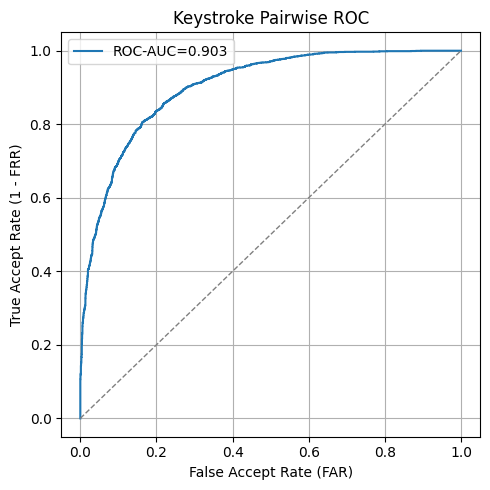


💾 Saved scorer → models/keystroke_scorer.joblib
💾 Saved metadata → models/keystroke_scoring_meta.json

✅ Done. Keystroke scorer is ready for use in streaming demos.


In [2]:
# ============================================================
# 04_keystroke_scoring.ipynb
# Adaptive Continuous Authentication — Keystroke Scoring
# ============================================================

"""
Goal:
  - Load keystroke embeddings (from 03_keystroke_encoders.ipynb)
  - Build genuine (same-user) and impostor (different-user) pairs
  - Train a simple scorer (logistic regression) on pairwise features
  - Evaluate ROC-AUC, EER, FRR@FAR=1%
  - Save scorer + metadata for later streaming demos

Artifacts:
  - models/keystroke_scorer.joblib
  - models/keystroke_scoring_meta.json
"""

# ============================================================
# Setup
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import json
import random

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import joblib
import matplotlib.pyplot as plt

# Paths
DATA_DIR = Path("data")
EMB_DIR = Path("embeddings")
MODEL_DIR = Path("models"); MODEL_DIR.mkdir(exist_ok=True)

FEATURES_PATH = DATA_DIR / "keystroke_features.npz"
EMB_CLS_PATH = EMB_DIR / "keystroke_embeddings_cls.npy"
EMB_AE_PATH  = EMB_DIR / "keystroke_embeddings_ae.npy"

# Config: choose which embeddings to use for scoring
USE_CLASSIFIER_EMB = True   # True → use 64-d CLS embeddings, False → 16-d AE embeddings

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ============================================================
# 1. Load embeddings + labels
# ============================================================

print("📥 Loading features + embeddings...")

meta = np.load(FEATURES_PATH, allow_pickle=True)
users = meta["user_id"].astype(str)
sessions = meta["session_id"].astype(str)

if USE_CLASSIFIER_EMB:
    Z = np.load(EMB_CLS_PATH).astype(np.float32)
    emb_name = "CLS"
else:
    Z = np.load(EMB_AE_PATH).astype(np.float32)
    emb_name = "AE"

print(f"Embeddings ({emb_name}):", Z.shape)
print("Unique users:", len(np.unique(users)))

# Basic sanity checks
assert Z.shape[0] == len(users), "Embeddings and labels length mismatch."

# ============================================================
# 2. Build pairwise dataset (genuine vs impostor)
# ============================================================

def build_pairs(Z, users, max_pos_per_user=200, neg_pos_ratio=1.0):
    """
    Construct a pairwise dataset:
      - Positive (label=1): same user, two different repetitions
      - Negative (label=0): different users

    Pair features are:
      - |z_i - z_j| (absolute difference)
      - z_i * z_j (elementwise product)

    Returns:
      X_pairs: (N_pairs, 2*dim)
      y_pairs: (N_pairs,)
    """
    Z = np.asarray(Z, dtype=np.float32)
    users = np.asarray(users)

    # Index samples by user
    by_user = {}
    for idx, u in enumerate(users):
        by_user.setdefault(u, []).append(idx)

    positives = []
    dim = Z.shape[1]

    # --- Build genuine pairs (same user) ---
    for u, idxs in by_user.items():
        if len(idxs) < 2:
            continue
        idxs = np.array(idxs)
        # Generate all pairs, then subsample up to max_pos_per_user
        all_pairs = []
        for i in range(len(idxs)):
            for j in range(i+1, len(idxs)):
                all_pairs.append((idxs[i], idxs[j]))
        random.shuffle(all_pairs)
        all_pairs = all_pairs[:max_pos_per_user]
        for i, j in all_pairs:
            zi, zj = Z[i], Z[j]
            diff = np.abs(zi - zj)
            prod = zi * zj
            feat = np.concatenate([diff, prod])
            positives.append(feat)

    if len(positives) == 0:
        raise RuntimeError("No positive pairs generated — check data.")

    X_pos = np.vstack(positives).astype(np.float32)
    y_pos = np.ones(len(X_pos), dtype=np.int64)

    # --- Build impostor pairs (different users) ---
    n_neg = int(len(X_pos) * neg_pos_ratio)
    negatives = []
    all_indices = np.arange(len(users))

    # To sample efficiently, create a mapping from user to indices
    user_list = list(by_user.keys())
    for _ in range(n_neg * 2):  # oversample attempts, we'll break when enough
        # Pick two different users
        u1, u2 = random.sample(user_list, 2)
        i = random.choice(by_user[u1])
        j = random.choice(by_user[u2])
        zi, zj = Z[i], Z[j]
        diff = np.abs(zi - zj)
        prod = zi * zj
        feat = np.concatenate([diff, prod])
        negatives.append(feat)
        if len(negatives) >= n_neg:
            break

    X_neg = np.vstack(negatives).astype(np.float32)
    y_neg = np.zeros(len(X_neg), dtype=np.int64)

    # --- Combine ---
    X_pairs = np.vstack([X_pos, X_neg])
    y_pairs = np.concatenate([y_pos, y_neg])

    X_pairs, y_pairs = shuffle(X_pairs, y_pairs, random_state=SEED)

    print(f"Pair dataset:")
    print("  X_pairs:", X_pairs.shape)
    print("  positives:", int(y_pairs.sum()))
    print("  negatives:", int((y_pairs == 0).sum()))
    return X_pairs, y_pairs

print("\n🔧 Building pairwise training set...")
X_pairs, y_pairs = build_pairs(Z, users, max_pos_per_user=200, neg_pos_ratio=1.0)

# ============================================================
# 3. Train logistic regression scorer
# ============================================================

print("\n🔧 Training logistic regression scorer...")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_pairs, y_pairs, test_size=0.25, stratify=y_pairs, random_state=SEED
)

scorer = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)
scorer.fit(X_tr, y_tr)

# Raw decision scores (prob(label=1))
scores = scorer.predict_proba(X_te)[:, 1]
auc = roc_auc_score(y_te, scores)
print(f"ROC-AUC (pairwise scorer): {auc:.4f}")

# ============================================================
# 4. Compute EER and FRR@FAR=1%
# ============================================================

def compute_eer(labels, scores):
    fpr, tpr, thr = roc_curve(labels, scores)
    fnr = 1 - tpr
    # EER is where FPR and FNR are closest
    idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fnr[idx] + fpr[idx]) / 2.0
    return float(eer), float(thr[idx]), fpr, tpr, thr

def frr_at_far(labels, scores, target_far=0.01):
    fpr, tpr, thr = roc_curve(labels, scores)
    idx = np.argmin(np.abs(fpr - target_far))
    frr = 1 - tpr[idx]
    return float(frr), float(thr[idx]), float(fpr[idx])

eer, thr_eer, fpr, tpr, thr = compute_eer(y_te, scores)
frr_1, thr_far1, far_achieved = frr_at_far(y_te, scores, target_far=0.01)

print("\n==== Keystroke Pairwise Scoring Results ====")
print(f"ROC-AUC         : {auc:.4f}")
print(f"EER             : {eer*100:.2f}%  @ threshold={thr_eer:.4f}")
print(f"FRR @ FAR=1%    : {frr_1*100:.2f}%  (achieved FAR={far_achieved*100:.2f}%)  @ threshold={thr_far1:.4f}")

# ============================================================
# 5. Plot ROC curve
# ============================================================

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"ROC-AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--', linewidth=1, color="gray")
plt.xlabel("False Accept Rate (FAR)")
plt.ylabel("True Accept Rate (1 - FRR)")
plt.title("Keystroke Pairwise ROC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# 6. Save scorer + metadata
# ============================================================

scorer_path = MODEL_DIR / "keystroke_scorer.joblib"
joblib.dump(scorer, scorer_path)
print("\n💾 Saved scorer →", scorer_path)

meta = {
    "embedding_type": emb_name,
    "embedding_dim": int(Z.shape[1]),
    "pair_feat_dim": int(X_pairs.shape[1]),
    "roc_auc": float(auc),
    "eer": float(eer),
    "eer_threshold": float(thr_eer),
    "frr_at_far_1pct": float(frr_1),
    "far_achieved_at_far_1pct": float(far_achieved),
    "threshold_far_1pct": float(thr_far1),
    "seed": SEED,
}

meta_path = MODEL_DIR / "keystroke_scoring_meta.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print("💾 Saved metadata →", meta_path)

print("\n✅ Done. Keystroke scorer is ready for use in streaming demos.")